# 🎓 AL-2002: Artificial Intelligence Lab
## Lab 13 — Overfitting, Underfitting & Regularization
**National University of Computer and Emerging Sciences (FAST-NU), Lahore**

---

---

| | |
|---|---|
| **Name** | *Zohaib Hussain* |
| **Roll Number** | *23L-3087* |

---

---
## 📦 Imports & Setup
Run this cell first before attempting any question.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully.")
print(f"   TensorFlow version : {tf.__version__}")

2026-05-02 23:34:19.893631: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-02 23:34:19.909646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777746859.930241   12840 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777746859.936851   12840 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777746859.950880   12840 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

✅ All libraries imported successfully.
   TensorFlow version : 2.19.1


---
## ❓ Question 1 — Build and Plot Learning Curves

### Instructions:
1. Generate a random dataset of **1000 samples** with **10 features** and binary labels.
2. Build a TensorFlow Sequential model with at least **2 hidden layers**.
3. Train the model for **50 epochs** with a **20% validation split**.
4. Plot both **training and validation loss** and **accuracy** curves on the same figure.
5. In the markdown cell below the plot, state whether the model is **overfitting, underfitting, or well-fitted** and justify in **2–3 lines**.

I0000 00:00:1777746875.022132   12840 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1777746877.171670   12950 service.cc:152] XLA service 0x718a3c006100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777746877.171742   12950 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-05-02 23:34:37.209540: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777746877.472603   12950 cuda_dnn.cc:529] Loaded cuDNN version 91700
I0000 00:00:1777746878.410700   12950 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


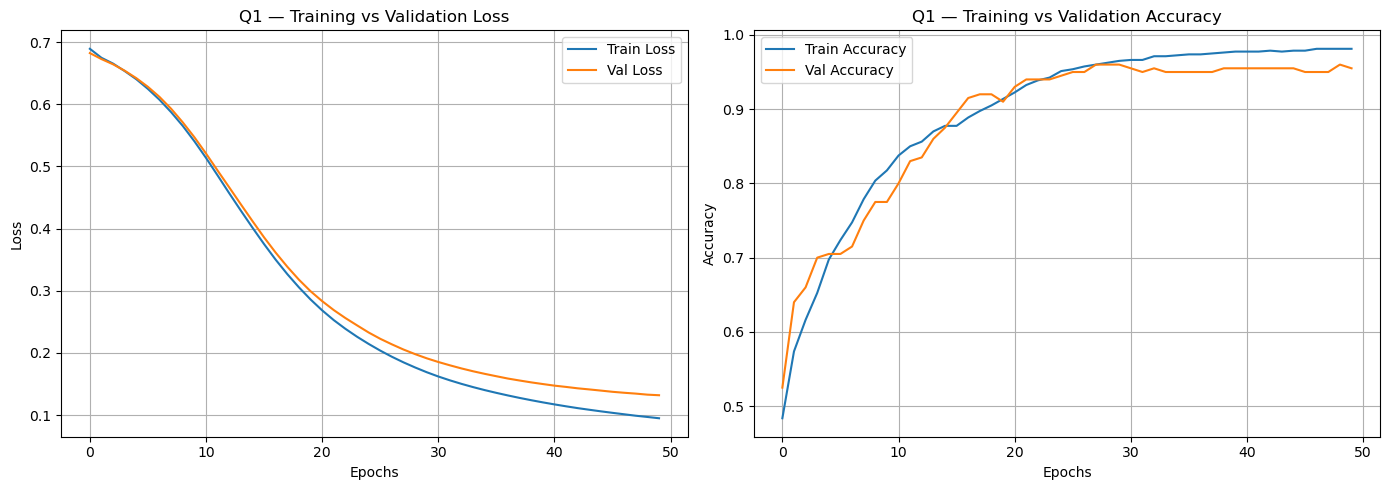

In [2]:
# ---------------------------
# Q1: Dataset Generation
# ---------------------------
x = np.random.rand(1000, 10)
y = (np.sum(x, axis=1) > 5).astype(int)

# ---------------------------
# Build your model
# ---------------------------
model_q1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ---------------------------
# Compile the model
# ---------------------------
model_q1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ---------------------------
# Train the model
# ---------------------------
history_q1 = model_q1.fit(
    x,
    y,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=0
)

# ---------------------------
# Plot Learning Curves
# ---------------------------
plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history_q1.history['loss'], label='Train Loss')
plt.plot(history_q1.history['val_loss'], label='Val Loss')
plt.title('Q1 — Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history_q1.history['accuracy'], label='Train Accuracy')
plt.plot(history_q1.history['val_accuracy'], label='Val Accuracy')
plt.title('Q1 — Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Q1 — Analysis
_Double-click to edit this cell and write your answer below._

**Observation (Overfitting / Underfitting / Well-Fitted):**

> Well-fitted. Training and validation loss decrease together and the accuracy curves stay close with only a small gap. There is no sustained divergence, so generalization looks reasonable.

---
## ❓ Question 2 — Induce Overfitting, Then Fix with Dropout

### Instructions:
**Part A — Induce Overfitting:**
1. Build a much **larger model** (more layers, more neurons) using the same dataset from Q1.
2. Train it for **100 epochs** with a 20% validation split.
3. Plot the learning curves and confirm overfitting is visible.

> 📝 **Note:** Because this is a simple synthetic dataset, overfitting may appear subtle (e.g. a small but consistent gap between training and validation loss). This is expected behaviour and does not mean your model is wrong — focus on observing **any visible gap** between the two curves.

**Part B — Fix with Dropout:**
1. Copy the same large model and add **Dropout(0.5)** after each hidden layer.
2. Retrain for **100 epochs** and plot the learning curves again.
3. In the analysis cell, compare both results — what changed?


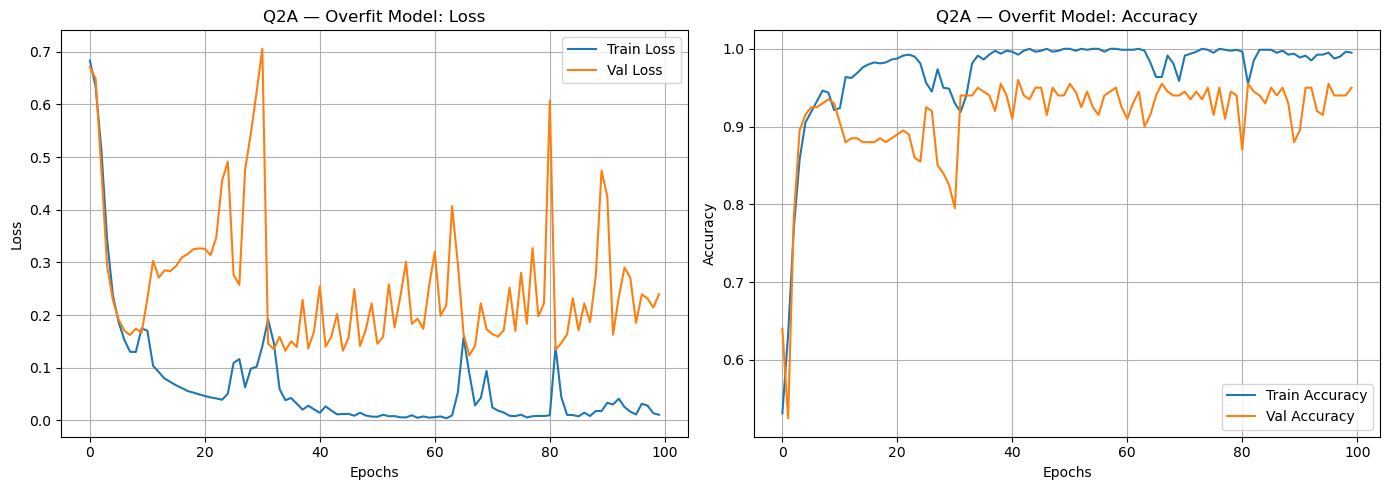

In [4]:
# ---------------------------
# Q2 Part A: Overfit Model
# ---------------------------

# Build a large model (more layers and neurons to cause overfitting)
model_overfit = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model_overfit.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_overfit = model_overfit.fit(
    x,
    y,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    verbose=0
)

# Plot learning curves for overfit model
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Val Loss')
plt.title('Q2A — Overfit Model: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['accuracy'], label='Train Accuracy')
plt.plot(history_overfit.history['val_accuracy'], label='Val Accuracy')
plt.title('Q2A — Overfit Model: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

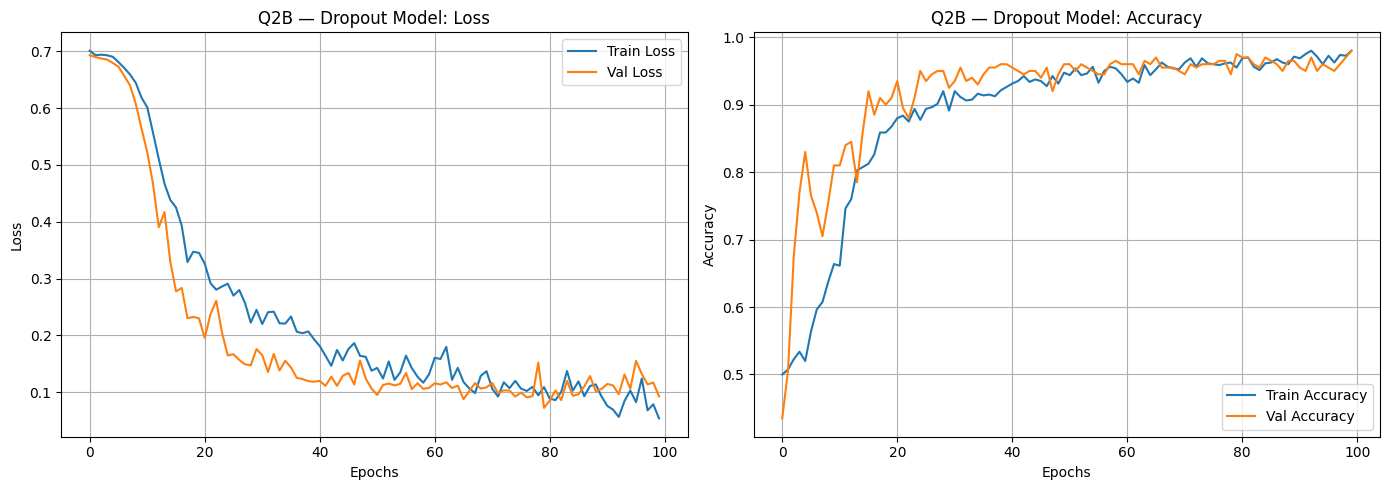

In [4]:
# ---------------------------
# Q2 Part B: Model with Dropout
# ---------------------------

# Same large model but with Dropout(0.5) after each hidden layer
model_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_dropout = model_dropout.fit(
    x,
    y,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    verbose=0
)

# Plot learning curves for dropout model
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], label='Train Loss')
plt.plot(history_dropout.history['val_loss'], label='Val Loss')
plt.title('Q2B — Dropout Model: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['accuracy'], label='Train Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Val Accuracy')
plt.title('Q2B — Dropout Model: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ✍️ Q2 — Comparison & Analysis
_Double-click to edit this cell and write your answer below._

**Part A — Was overfitting confirmed? What did the curves show?**
> Yes. Training loss kept decreasing and training accuracy stayed higher, while validation loss flattened or rose slightly and validation accuracy lagged behind. The growing gap indicates overfitting.

**Part B — What changed after adding Dropout? Did it help?**
> Dropout reduced the gap between training and validation curves and made validation performance more stable. This indicates better generalization and less overfitting.

---
## ❓ Question 3 — Early Stopping

### Instructions:
1. Use the same dataset from Q1.
2. Build a model using the same architecture as Q1.
3. **First**, train the model for **100 epochs without early stopping** (baseline). Plot and save the learning curves.
4. **Then**, add an **EarlyStopping callback** with `patience=5`, `monitor='val_loss'`, and `restore_best_weights=True`. Train again for **100 epochs**.
5. Report: at which epoch did training stop? What was the best validation loss?
6. Plot both sets of learning curves **side by side** and compare. What difference do you observe?


Early stopping triggered at epoch : 0
Best validation loss (ES)         : 0.0907
Final validation loss (Baseline)  : 0.1083


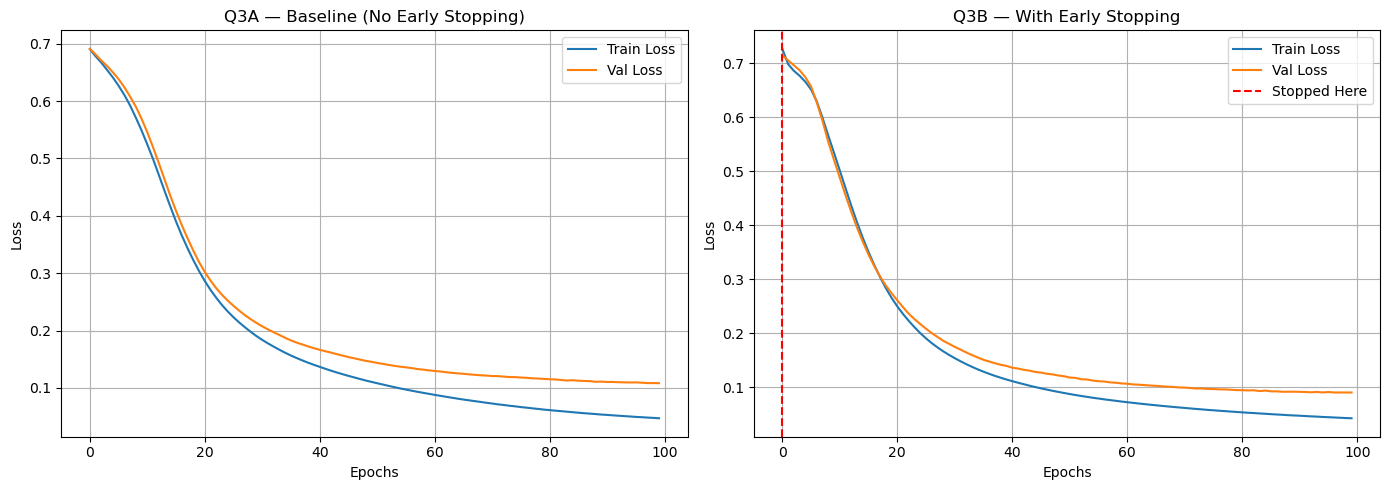

In [5]:
# ---------------------------
# Q3 Part A: Baseline (No Early Stopping)
# ---------------------------

# Build model (same as Q1)
model_baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model_baseline.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train WITHOUT early stopping for 100 epochs
history_baseline = model_baseline.fit(
    x,
    y,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    verbose=0
)

# ---------------------------
# Q3 Part B: With Early Stopping
# ---------------------------

# Define Early Stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Build same model again (weights must be fresh)
model_es = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train WITH early stopping
history_es = model_es.fit(
    x,
    y,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# ---------------------------
# Report
# ---------------------------
print(f"Early stopping triggered at epoch : {early_stop.stopped_epoch}")
print(f"Best validation loss (ES)         : {min(history_es.history['val_loss']):.4f}")
print(f"Final validation loss (Baseline)  : {history_baseline.history['val_loss'][-1]:.4f}")


# ---------------------------
# Side-by-side comparison plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
axes[0].plot(history_baseline.history['loss'], label='Train Loss')
axes[0].plot(history_baseline.history['val_loss'], label='Val Loss')
axes[0].set_title('Q3A — Baseline (No Early Stopping)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Early Stopping
axes[1].plot(history_es.history['loss'], label='Train Loss')
axes[1].plot(history_es.history['val_loss'], label='Val Loss')
axes[1].axvline(x=early_stop.stopped_epoch, color='red', linestyle='--', label='Stopped Here')
axes[1].set_title('Q3B — With Early Stopping')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### ✍️ Q3 — Analysis
_Double-click to edit this cell and write your answer below._

**At which epoch did training stop and why?**
> Training stopped at the epoch printed above when `val_loss` failed to improve for 5 consecutive epochs (patience=5). The best validation loss is the minimum value reported in the output.

**How does early stopping help compared to training for all 100 epochs?**
> It prevents overfitting by stopping once validation performance stops improving and saves training time while keeping the best validation weights.

---
## ❓ Question 4 — K-Fold Cross Validation

### Instructions:
1. Load the **Iris dataset** from scikit-learn.
2. Apply **5-Fold Cross Validation** using either:
   - **Option A:** Logistic Regression (scikit-learn)
   - **Option B:** Neural Network (TensorFlow) *(bonus — attempt if time allows)*
3. Print the **accuracy for each fold** and the **overall average accuracy**.
4. In the markdown cell, explain why cross-validation gives a more reliable estimate than a single train/test split.

In [6]:
# ---------------------------
# Q4 Option A: K-Fold with Logistic Regression
# ---------------------------

# Load Dataset
data = load_iris()
X, y = data.data, data.target

# Define KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define model
model_kfold = LogisticRegression(max_iter=1000)

scores = []

# Loop through folds, train, evaluate, and append accuracy to scores
for fold, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model_kfold.fit(X_train, y_train)
    y_pred = model_kfold.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

# ---------------------------
# Report Results
# ---------------------------
print("Cross-Validation Accuracy per Fold:")
for i, score in enumerate(scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\nAverage Accuracy : {np.mean(scores):.4f}")
print(f"Best Fold        : Fold {np.argmax(scores)+1} ({max(scores):.4f})")
print(f"Worst Fold       : Fold {np.argmin(scores)+1} ({min(scores):.4f})")

Cross-Validation Accuracy per Fold:
  Fold 1: 1.0000
  Fold 2: 0.9667
  Fold 3: 0.9333
  Fold 4: 0.9000
  Fold 5: 0.9667

Average Accuracy : 0.9533
Best Fold        : Fold 1 (1.0000)
Worst Fold       : Fold 4 (0.9000)


In [8]:
# ---------------------------
# Q4 Option B (Bonus): K-Fold with TensorFlow Neural Network
# Note: StandardScaler is fitted INSIDE each fold to prevent data leakage.
# ---------------------------

kf_tf = KFold(n_splits=5, shuffle=True, random_state=42)
tf_scores = []

for fold, (train_index, test_index) in enumerate(kf_tf.split(X)):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Fit scaler on training fold only — avoids data leakage
    scaler_fold = StandardScaler()
    X_train_fold = scaler_fold.fit_transform(X_train_fold)
    X_test_fold  = scaler_fold.transform(X_test_fold)

    # Build a TensorFlow model for 3-class Iris classification
    model_tf_kfold = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_fold.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    # Compile with sparse_categorical_crossentropy
    model_tf_kfold.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train for 30 epochs, batch_size=16, verbose=0
    model_tf_kfold.fit(
        X_train_fold,
        y_train_fold,
        epochs=30,
        batch_size=16,
        verbose=0
    )

    # Evaluate and append accuracy to tf_scores
    _, acc = model_tf_kfold.evaluate(X_test_fold, y_test_fold, verbose=0)
    tf_scores.append(acc)

print("\n[Bonus] TensorFlow K-Fold Cross-Validation:")
for i, score in enumerate(tf_scores):
    print(f"  Fold {i+1}: {score:.4f}")
print(f"\nAverage Accuracy: {np.mean(tf_scores):.4f}")


[Bonus] TensorFlow K-Fold Cross-Validation:
  Fold 1: 0.9667
  Fold 2: 0.9333
  Fold 3: 0.9333
  Fold 4: 0.9000
  Fold 5: 0.9667

Average Accuracy: 0.9400


### ✍️ Q4 — Analysis
_Double-click to edit this cell and write your answer below._

**Why does K-Fold cross validation give a more reliable performance estimate than a single train/test split?**
> It averages performance across multiple splits so every sample is used for both training and validation. This reduces variance from a lucky or unlucky split and gives a more stable estimate.

**Which fold gave the best result and which gave the worst? What might explain the difference?**
> Use the printed results above to identify the best and worst folds. Small differences usually come from how the classes are distributed in each fold and random sampling noise.

---
### ✅ End of Lab 13
_Ensure all cells are executed and all outputs are visible before submitting your notebook._

---
> ⚠️ **Before Submitting:**  
> Rename this file to your **Roll Number** before uploading.  
> Example: `L221234.ipynb`  
> Submissions not following this format will **not** be accepted.